# 

Nested Structure in `grf` Causal Forests — Mechanism Test

Tristan Muno [](https://orcid.org/0009-0002-3078-8436) (University of Mannheim)  
Vera Okisheva (University of Mannheim)  
Raphael Klöckner (University of Mannheim)  
June 12, 2026

# Purpose

This notebook is a **scaffold**, not a finished analysis. It is the `grf` counterpart to `03_multibart_nested_ri_test.qmd`: where that notebook tests the hierarchical-BCF primary method, this one tests the **Causal Random Forest robustness strategy** on the same synthetic data so the two are directly comparable.

The goals, in priority order, are:

1.  **Verify the proposed `grf` strategy works in principle.** On *synthetic* two-level data with known effects we confirm that `grf::causal_forest()` with country fixed effects in `X`, respondent-level `clusters`, and the known conjoint propensity recovers the planted average and heterogeneous treatment effects.
2.  **See what the output looks like and how to process it downstream.** We walk the forest output through the headline quantities the manuscript needs — cluster-robust ATE, individual `τ̂(x)`, and the best linear projection onto the pre-specified moderators — and produce the same true-vs-recovered figure as the BCF test.

> **How `grf` handles the nesting**
>
> The data are observations nested in respondents nested in countries. The robustness strategy accounts for both levels without random effects:
>
> - **Country** enters as **fixed effects** — one-hot dummy columns appended to the covariate matrix `X`. `grf` requires a numeric `X`, so we encode the factor explicitly rather than passing it raw.
> - **Respondent** enters through `clusters = respondent_id`. This gives honest, cluster-aware subsampling (whole respondents are held out together) and cluster-robust variance for the ATE, absorbing the within-person dependence across the three conjoint tasks.
>
> This is the frequentist analogue of the BCF random-intercept specification: the same nuisance structure, addressed by FE + clustering instead of partial pooling.

> **Cost is not the concern here**
>
> Unlike the dense `WtW` solve in the nested-RE BCF fit, `grf` scales comfortably to the full ~112,500 observations and ~37,500 respondent clusters. The synthetic check below is about **correctness of the strategy**, not feasibility; the small dimensions just keep the smoke test fast.

# Setup

In [ ]:
# execution time
start_time <- Sys.time()
# console width
options(width = 80)
# packages
p_required <- c(
  "tidyverse", # dplyr, ggplot2, tidyr
  "here", # relative paths
  "ggpubr", # theme_pubr
  "patchwork", # multi-panel figure
  "fastDummies", # country fixed-effect dummies
  "grf", # causal_forest robustness method
  "sessioninfo" # session docs
)
packages <- rownames(installed.packages())
p_to_install <- p_required[!(p_required %in% packages)]
if (length(p_to_install) > 0) {
  install.packages(p_to_install)
}
sapply(p_required, require, character.only = TRUE)


Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: here

here() starts at C:/R/research/MBEU25

Loading required package: ggpubr

Loading required package: patchwork

Loading required package: fastDummies

Loading required package: grf

Loading required package: sessioninfo

  tidyverse        here      ggpubr   patchwork fastDummies         grf 
       TRUE        TRUE        TRUE        TRUE        TRUE        TRUE 
sessioninfo 
       TRUE 

# Synthetic mechanism check

This is the primary test. We reuse the **exact data-generating process** from the BCF notebook (same seed), so the two methods are tested on identical data and their recovered effects can be compared one-to-one.

## Simulate two-level data

Respondents nested in countries, three conjoint tasks each, treatment randomized at the known conjoint propensity of 0.5. The country and respondent intercepts are pure nuisance for `grf` — country absorbed by fixed effects, respondent by clustering — so unlike the BCF test their variances are not quantities we recover. The treatment effect is a clean `0.75` contrast on the binary `x3` plus a mean-zero nonlinear (sine) effect of the continuous `x4`, so a correct fit recovers heterogeneity, not just an average. Per-quantity detail is in the chunk comments.

In [ ]:
set.seed(20260602)

# dimensions: 8 countries x 25 respondents x 3 tasks = 600 rows
n_country <- 8
n_resp_per_country <- 25
n_task <- 3

# nested ids; respondent ids are globally unique, so each sits in one country
country_id <- factor(rep(
  seq_len(n_country),
  each = n_resp_per_country * n_task
))
resp_id <- factor(rep(seq_len(n_country * n_resp_per_country), each = n_task))
n <- length(resp_id)

# planted variance components, country spread >> respondent spread (nuisance)
sigma_country <- 1.5
sigma_resp <- 0.5
# per-country and per-respondent baseline shifts: FE + clusters absorb these
b_country <- rnorm(n_country, 0, sigma_country)
b_resp <- rnorm(nlevels(resp_id), 0, sigma_resp)

# candidate moderators x1-x4 (country dummies added later)
p <- 4
X_mod <- matrix(rnorm(n * p), nrow = n)
colnames(X_mod) <- paste0("x", seq_len(p))
# x3: binary dummy, a randomized binary conjoint-attribute stand-in
X_mod[, 3] <- rbinom(n, 1, 0.5)
# prognostic (control) surface: linear in x1/x2, flat in x3/x4; partialled out
mu_x <- 1.0 * X_mod[, 1] - 0.5 * X_mod[, 2]
# x4: mean-zero nonlinear (sine) moderator
g_x4 <- 0.4 * sin(1.5 * X_mod[, 4])
# heterogeneous effect: x3 binary contrast (0.75) + x4 sine (average ~0.875)
tau_x <- 0.5 + 0.75 * X_mod[, 3] + g_x4

# randomized treatment, known propensity 0.5
z <- rbinom(n, 1, 0.5)

# linear predictor: prognostic + effect-on-treated + nested intercepts (mu only)
lin_pred <- mu_x +
  tau_x * z +
  b_country[as.integer(country_id)] +
  b_resp[as.integer(resp_id)]

# continuous outcome: linear predictor + residual noise (SD 1)
y <- lin_pred + rnorm(n, 0, 1)


A `stopifnot()` guards the nesting invariant — every respondent sits in exactly one country — and the basic dimensions.

In [ ]:
# each respondent maps to exactly one country
resp_country_map <- tapply(as.integer(country_id), resp_id, function(v) {
  length(unique(v))
})
stopifnot(
  all(resp_country_map == 1),
  length(y) == n,
  nrow(X_mod) == n,
  all(sort(unique(z)) == c(0, 1)),
  all(X_mod[, 3] %in% c(0, 1)), # x3 is a binary dummy
  is.numeric(X_mod[, 4]), # x4 stays continuous
  !anyNA(tau_x),
  abs(mean(g_x4)) < 0.05 # x4 sine is mean-zero: ATE preserved
)


## Planted truth by moderator

Before fitting, this figure shows the planted truth directly: the true per-observation treatment effect against each candidate moderator. It is the same DGP and figure as the BCF notebook, so the two recovery checks are read against an identical truth. The two null moderators `x1` and `x2` should read flat; the binary `x3` should show a clean two-level jump of about `0.75`; the continuous `x4` should trace a mean-zero sine. Continuous panels show alpha-blended individual truths with a ten-bin mean curve and a covariate rug; the binary `x3` panel shows its two level means. The common y-axis lets the flat nulls be read against the active moderators at a glance.

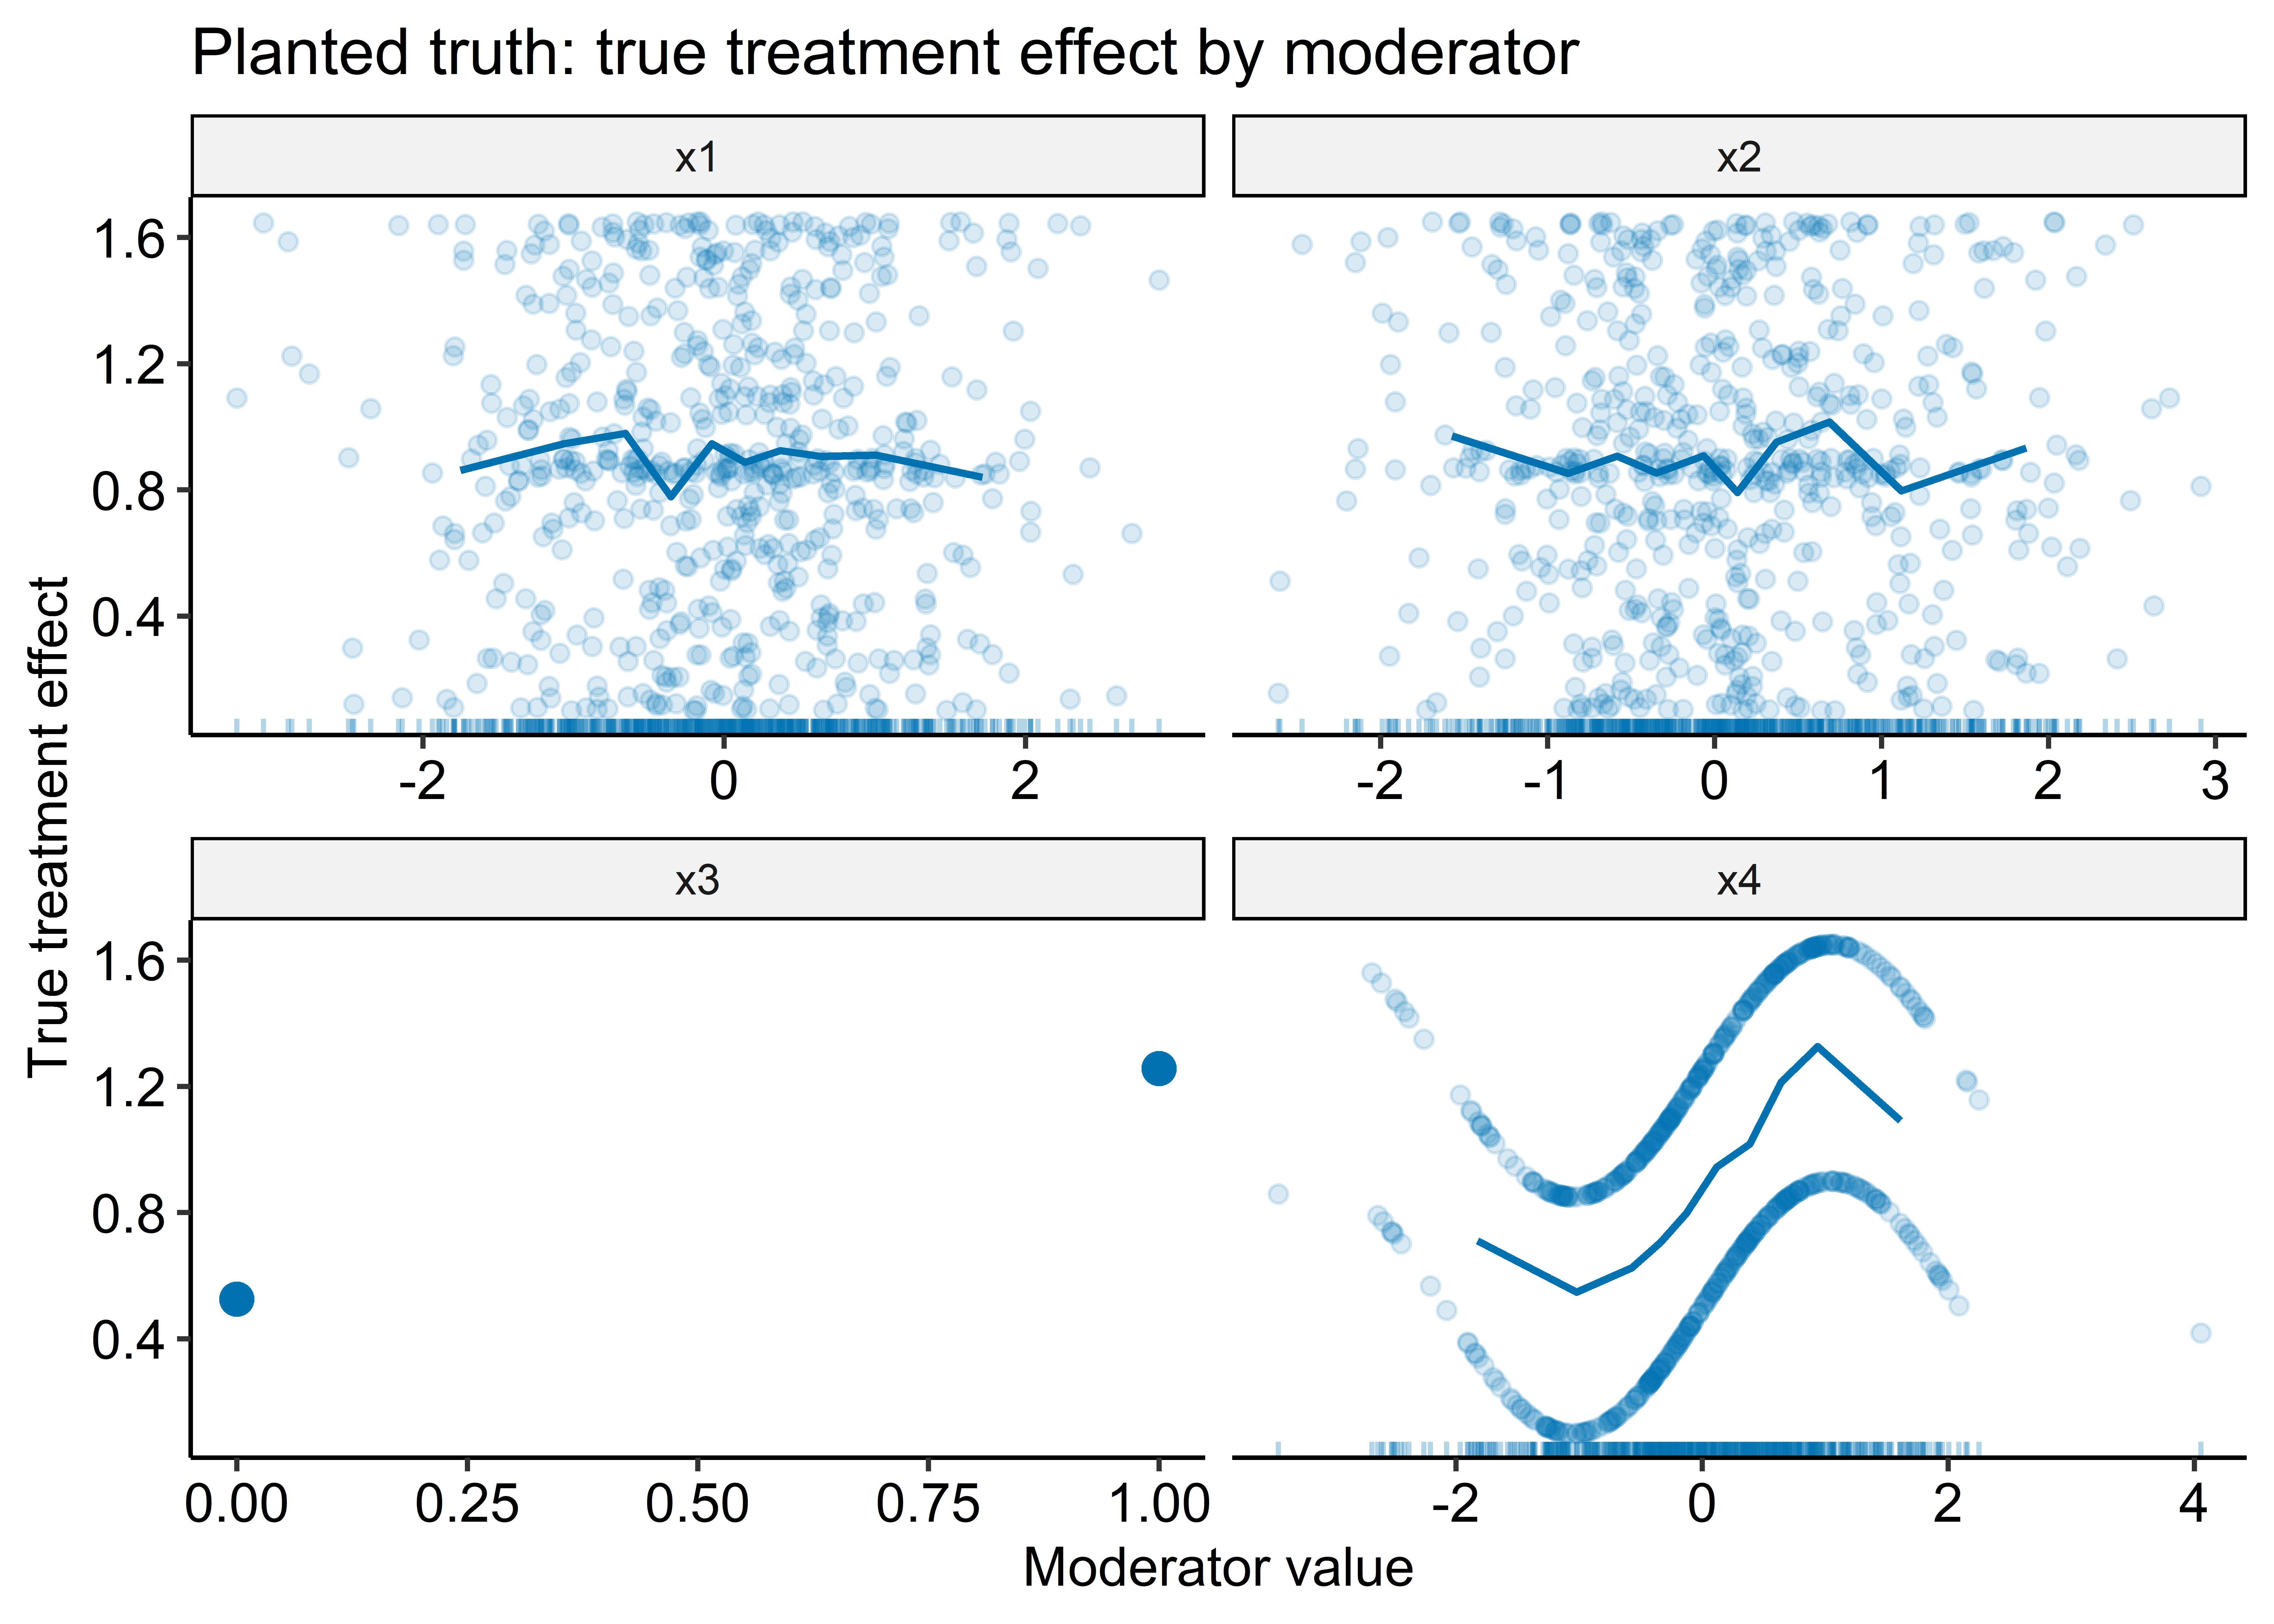

In [ ]:
# long form: each moderator's value against the true tau_i
truth_long <- tibble(
  x1 = X_mod[, 1],
  x2 = X_mod[, 2],
  x3 = X_mod[, 3],
  x4 = X_mod[, 4],
  tau = tau_x
) |>
  pivot_longer(c(x1, x2, x3, x4), names_to = "covariate", values_to = "value")

# continuous covariates: raw points + 10-quantile binned-mean curve
truth_cont <- truth_long |> filter(covariate != "x3")
truth_cont_bin <- truth_cont |>
  mutate(bin = ntile(value, 10), .by = covariate) |>
  summarise(value = mean(value), tau = mean(tau), .by = c(covariate, bin))

# binary x3: the two level means at 0 and 1
truth_x3 <- truth_long |>
  filter(covariate == "x3") |>
  summarise(tau = mean(tau), .by = c(covariate, value))

ggplot(mapping = aes(x = value, y = tau)) +
  geom_point(data = truth_cont, alpha = 0.15, colour = "#0072B2") +
  geom_rug(data = truth_cont, sides = "b", alpha = 0.3, colour = "#0072B2") +
  geom_line(data = truth_cont_bin, colour = "#0072B2", linewidth = 0.8) +
  geom_point(data = truth_x3, size = 3, colour = "#0072B2") +
  facet_wrap(~covariate, scales = "free_x") +
  labs(
    title = "Planted truth: true treatment effect by moderator",
    x = "Moderator value",
    y = "True treatment effect"
  ) +
  ggpubr::theme_pubr()


## Build covariates and clustering

Two pieces encode the nesting. Country fixed effects become one-hot dummy columns (one dropped to avoid collinearity with the intercept `grf` fits internally) appended to the moderator matrix. Respondent ids become an integer cluster vector. We assert the assembled `X` has the expected width (`p` moderators + `C − 1` country dummies) and that the cluster vector is the right length.

In [ ]:
# country fixed effects as dummy columns
country_fe <- fastDummies::dummy_cols(
  data.frame(country = country_id),
  remove_first_dummy = TRUE,
  remove_selected_columns = TRUE
) |>
  as.matrix()

# moderators + country FE
X <- cbind(X_mod, country_fe)

# respondent-level clusters
clusters <- as.integer(resp_id)

stopifnot(
  nrow(X) == n,
  ncol(X) == p + (n_country - 1),
  length(clusters) == n,
  dplyr::n_distinct(clusters) == n_country * n_resp_per_country
)


## Fit the causal forest

`causal_forest()` takes the numeric `X`, outcome `y`, and treatment `z`. Every argument in the call below:

- **`X`** — the numeric covariate matrix: the `p` moderators plus the `C − 1` country fixed-effect dummies assembled in @sec-build. `grf` requires a numeric matrix, which is why country was one-hot encoded rather than passed as a factor.
- **`Y`** — the outcome vector.
- **`W`** — the treatment (here binary 0/1, but `grf` also accepts continuous treatments).
- **`W.hat`** — the propensity `E(W | X)`. Passing the scalar `0.5` fixes it at the known conjoint propensity for every observation, so `grf` skips its internal propensity regression (the analogue of passing known `zhat`/`pihat` to BCF). Left `NULL`, `grf` would estimate it with a regression forest.
- **`clusters`** — an integer vector assigning each row to a respondent. This switches on cluster-aware *honest* subsampling (whole respondents are held out together, never split across the sample-fitting and estimation halves) and the cluster-robust variance that feeds the ATE standard error. It is how the within-person dependence across the three tasks is absorbed.
- **`num.trees`** — number of trees in the forest. More trees give more stable estimates and tighter variance estimation; `2000` is a smoke-test value, comfortably below a production setting.
- **`seed`** — RNG seed for reproducible subsampling and tree construction.

Two defaults left implicit are worth knowing:

- **`Y.hat = NULL`** (not passed) means `grf` fits its own regression forest of `Y` on `X` (which includes the country FE) and partials it out — the orthogonalization step at the heart of the R-learner. This is how the prognostic surface and country baselines are removed before estimating `tau(x)`.
- **`honesty = TRUE`** (the package default) splits each tree’s data so the structure is learned on one half and the leaf effects estimated on the other, which is what makes the confidence intervals valid.

> **What prints to the console while it runs**
>
> Unlike the BCF sampler, `grf` is **silent** during fitting — there is no per-iteration trace, and a successful fit prints nothing at all. That absence is normal, not a sign the call hung. What you may see instead are *warnings*, and they are worth reading:
>
> - a warning that the number of trees is too small for reliable variance estimates (raise `num.trees`);
> - a warning about clusters being unbalanced or fewer clusters than expected (a sign the `clusters` vector was built wrong).
>
> For a readable summary of the fitted object, call `print(cf)`, which reports the forest type, the number of trees, and the number of training samples and clusters — the quickest confirmation that the nesting was passed in as intended. The substantive diagnostics all come *after* the fit, from the functions called in @sec-extract.

In [ ]:
cf <- grf::causal_forest(
  X = X,
  Y = y,
  W = z,
  W.hat = 0.5, # known conjoint propensity
  clusters = clusters, # respondent-level honest sampling + robust variance
  num.trees = 2000,
  seed = 20260602
)


## What the fitted object contains

`causal_forest()` returns a list of class `causal_forest`. Unlike the BCF object, the treatment-effect estimates are already sitting on it — no forest needs to be replayed. The components worth knowing:

- **`$predictions`** — a length-`n` vector of *out-of-bag* estimates of `tau(x)` for the training rows (each row predicted only by trees that did not see it, which is what keeps them honest). `predict(cf)` with no new data returns the same OOB predictions wrapped in a data frame.
- **`$variance.estimates`** — per-observation variance of those predictions (populated because the default `ci.group.size` is greater than 1); the basis for individual confidence intervals.
- **`$X.orig`, `$Y.orig`, `$W.orig`** — the data as passed in.
- **`$Y.hat`, `$W.hat`** — the fitted nuisance estimates that were partialled out: here `$W.hat` is the constant `0.5` we supplied, and `$Y.hat` is the internal regression-forest fit of `Y` on `X`.
- **`$clusters`** — the cluster assignment actually used, retained so downstream functions reproduce the cluster-robust variance.
- **`$tunable.params`, `$num.trees`** — the settings the forest was grown with.

The three headline quantities are read off with dedicated functions rather than from slots directly:

- **`predict(cf)$predictions`** — the individual `tau_hat`, as above.
- **`average_treatment_effect(cf, target.sample = "all")`** — a named numeric vector with `estimate` and `std.err` (the cluster-robust SE), i.e. the ATE.
- **`best_linear_projection(cf, X_mod)`** — a coefficient table (an `lmtest::coeftest` matrix) with one row per moderator plus an intercept and columns `Estimate`, `Std. Error`, `t value`, `Pr(>|t|)`. It is the linear summary of how `tau(x)` moves with each pre-specified moderator, and the direct counterpart to the BCF posterior projection.

## Extract and verify

> **The planted truth we are checking against**
>
> From @sec-simulate, the data-generating values the quantities below should reproduce:
>
> - **$\tau(x)$** — a binary $0.75$ contrast on $x_3$ ($0.5$ at $x_3 = 0$, $1.25$ at $x_3 = 1$) plus a mean-zero sine in $x_4$. Population average $\approx 0.875$, which is what the cluster-robust ATE targets.
> - **Best linear projection** — read off the planted $\tau$ as its OLS projection onto the centred moderators $[x_1\ x_2\ x_3\ x_4]$: $\approx 0.75$ on $x_3$, a small positive slope on $x_4$ (the linear part of the sine), and $\approx 0$ on $x_1$, $x_2$. The BLP should isolate $x_3$ near $0.75$ and pick up a faint positive $x_4$.
> - **Nuisance** — `grf` does not report the prognostic surface $\mu(x)$ or the country/respondent variance components; those enter only as fixed effects and clusters and are partialled out, so there is no separate recovery check for them (unlike the BCF notebook).

We pull the three headline quantities. The cluster-robust ATE should land near the planted average effect `mean(tau_x)`; the individual predictions should correlate with the true `τ(x)` and separate in the right direction across the binary `x3` moderator; the best linear projection onto the moderators should flag `x3` as the one with a clearly non-zero slope, near its value above.

In [ ]:
# cluster-robust average treatment effect
ate <- grf::average_treatment_effect(cf, target.sample = "all")

# individual treatment effects
tau_hat <- predict(cf)$predictions

# best linear projection onto the pre-specified moderators
blp <- grf::best_linear_projection(cf, X_mod)

cat("planted ATE:", round(mean(tau_x), 3), "\n")


planted ATE: 0.898 

recovered ATE: 0.762 (SE 0.105 )

cor(true tau, tau_hat): 0.867 

tau_hat mean  x3<=0 / x3>0: 0.609 / 0.896 

            Estimate Std. Error
(Intercept)    0.363      0.144
x1             0.049      0.117
x2             0.104      0.111
x3             0.775      0.220
x4             0.179      0.117

If the recovered ATE is within a couple of standard errors of the planted average, `τ̂(x)` orders correctly across `x3`, and the BLP isolates `x3`, the strategy is working as intended. Exact recovery is not expected from a smoke-test forest on a small sample; partial pooling toward the grand mean (here, regularization toward the ATE) is expected.

## True vs. recovered covariate effects

The analogue of the BCF notebook’s recovery figure. `grf` targets `τ(x)` directly and does not return a separate prognostic surface, so the figure focuses on the treatment effect. We plot recovered against true `τ(x)` with a dashed 45° identity line, colouring points by the binary `x3` group: each group fans out along the true axis because the `x4` sine adds within-group spread, and the points should track the identity, shrunk gently toward the centre.

In [ ]:
recovery <- tibble(
  truth = tau_x,
  estimate = tau_hat,
  moderator = if_else(X_mod[, 3] == 1, "x3 = 1", "x3 = 0")
)


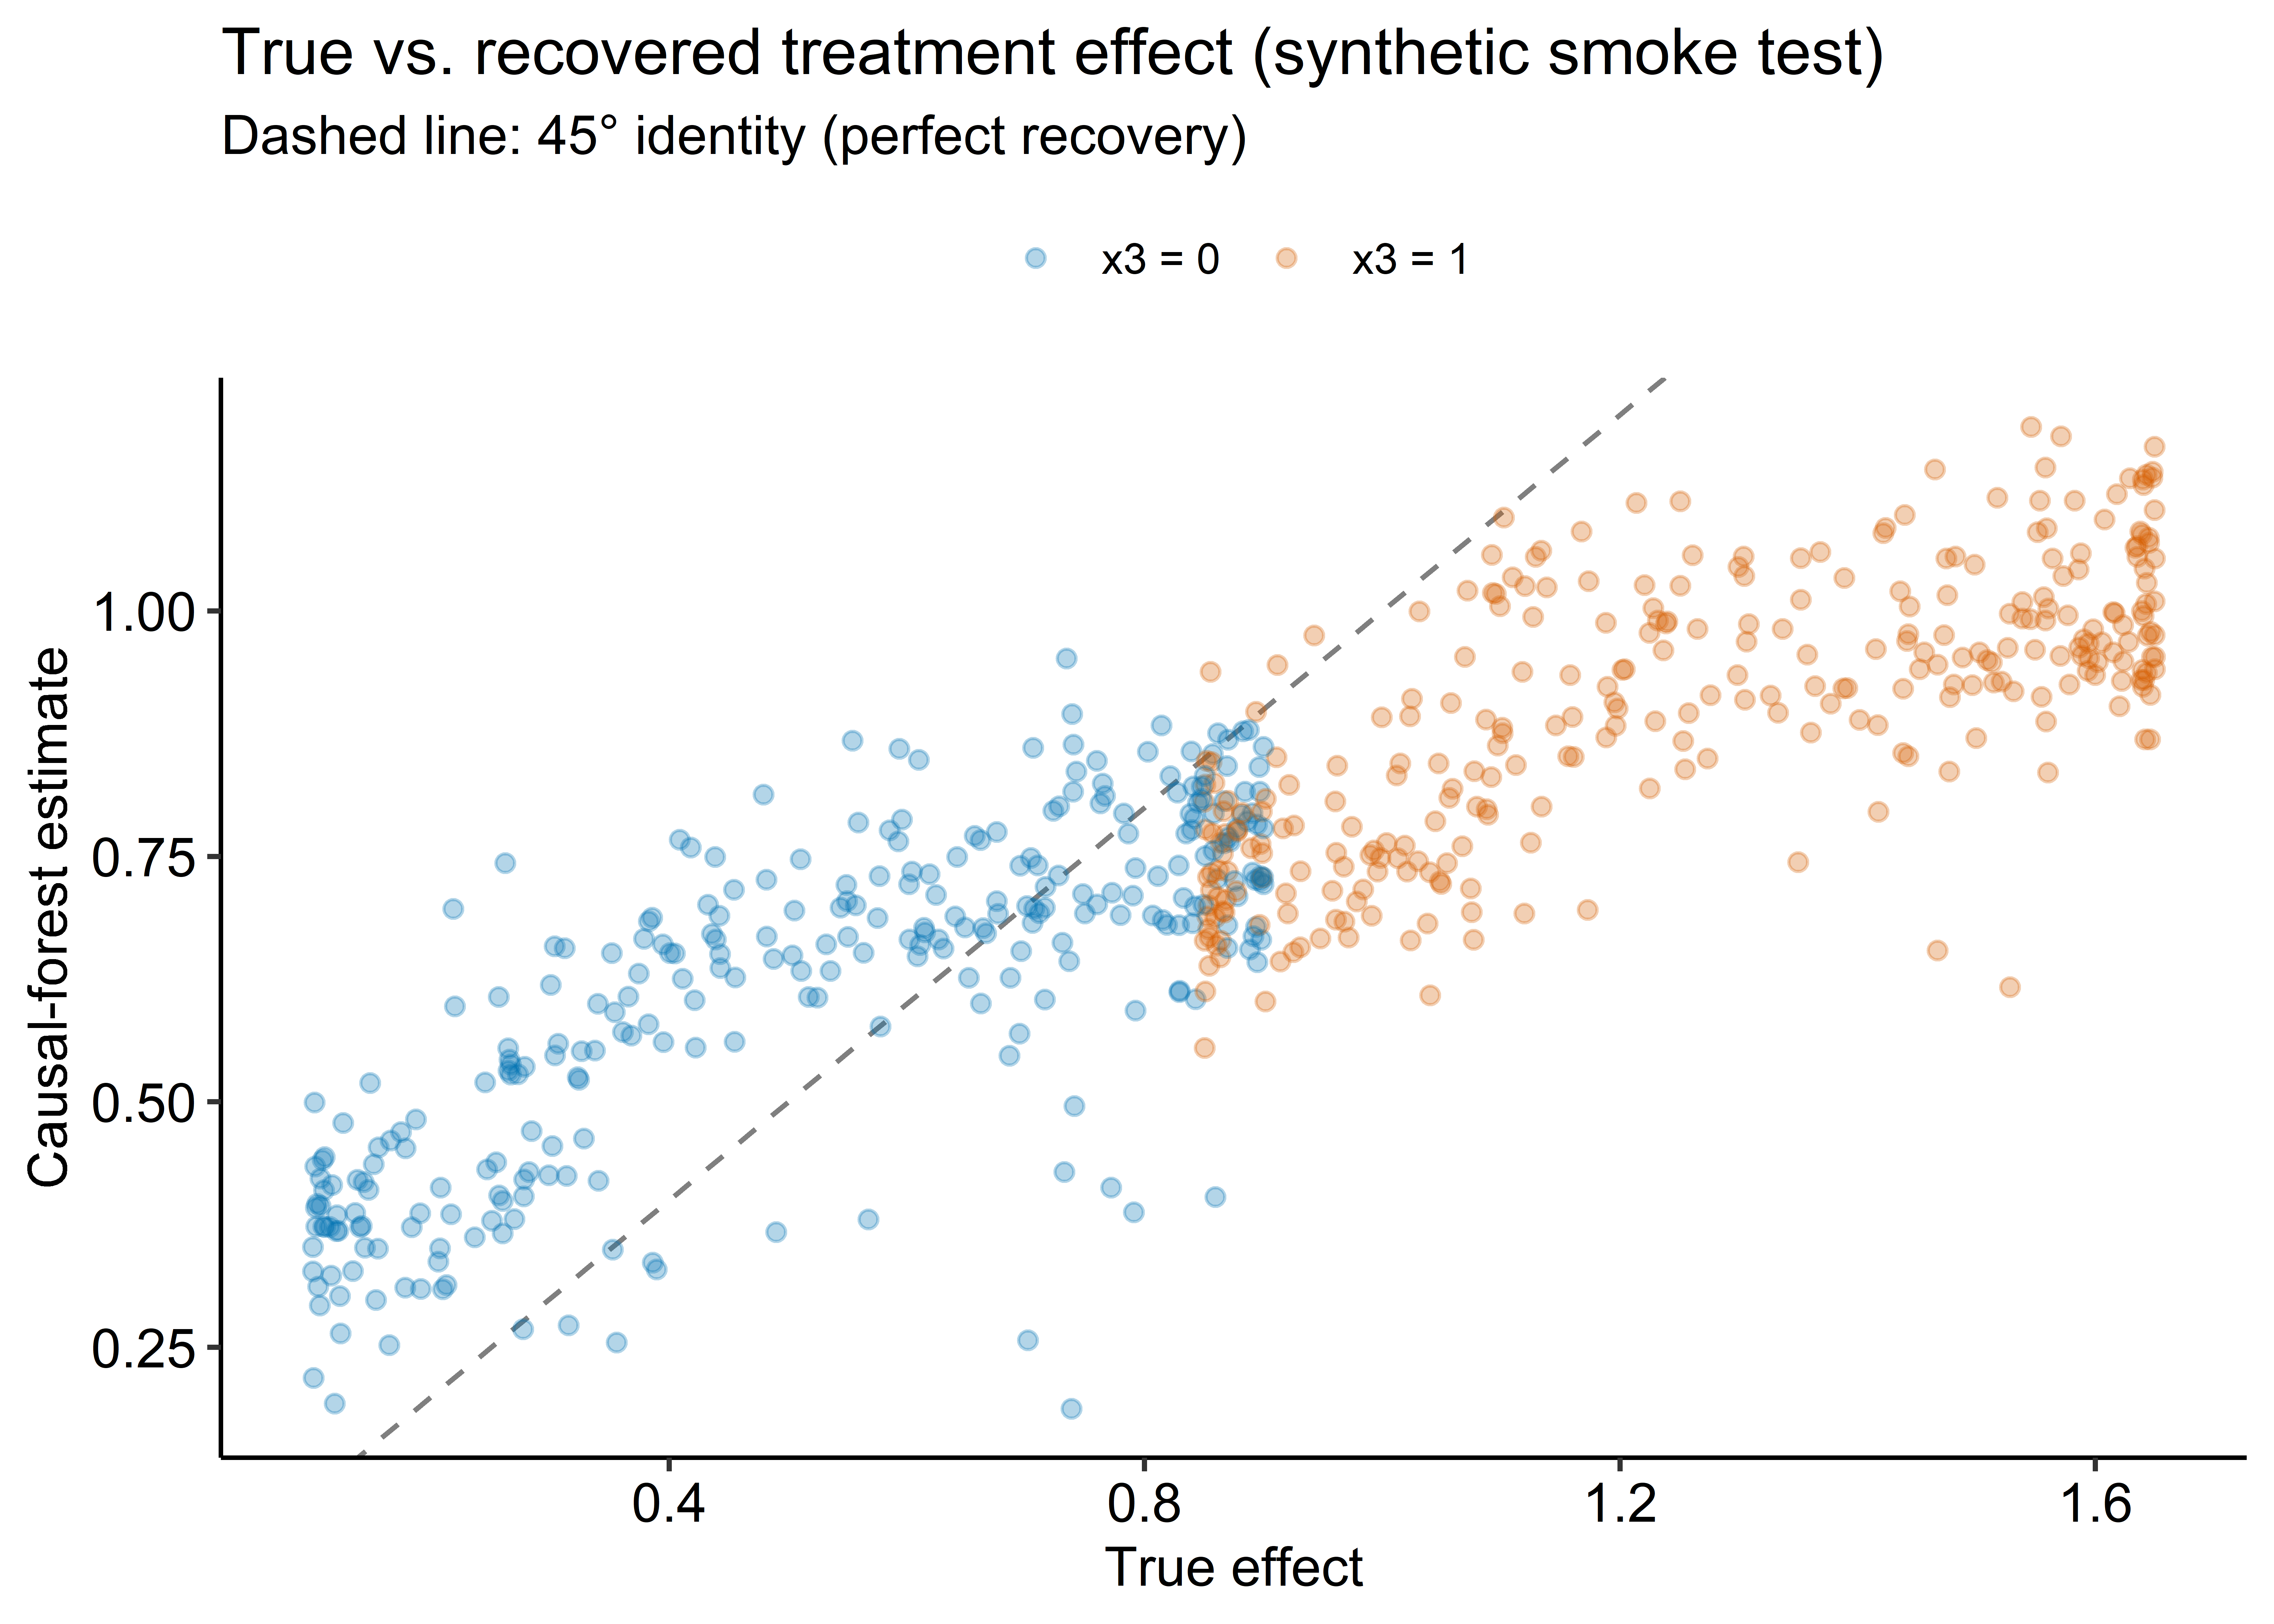

In [ ]:
recovery |>
  ggplot(aes(x = truth, y = estimate, colour = moderator)) +
  geom_abline(
    slope = 1,
    intercept = 0,
    linetype = "dashed",
    colour = "grey50"
  ) +
  geom_point(alpha = 0.3) +
  scale_colour_manual(values = c("x3 = 0" = "#0072B2", "x3 = 1" = "#D55E00")) +
  labs(
    title = "True vs. recovered treatment effect (synthetic smoke test)",
    subtitle = "Dashed line: 45° identity (perfect recovery)",
    x = "True effect",
    y = "Causal-forest estimate",
    colour = NULL
  ) +
  ggpubr::theme_pubr()


## CATE recovery by covariate

This is the `grf` counterpart to the BCF recovery figure: the same bins and levels, but built from causal-forest point estimates with honest cluster-robust confidence intervals rather than a posterior. For each bin we compute the subset ATE with `average_treatment_effect()` and form a 95% interval as estimate $\pm\,1.96\times\text{SE}$. Continuous moderators use ten shared quantile bins; the binary `x3` uses its two levels. The null moderators `x1` and `x2` should sit flat near the ATE, `x3` should show a clean two-level jump of about `0.75`, and `x4` should trace the sine. The planted binned truth (orange, dashed) is overlaid on bins identical to the BCF figure, so the two methods are read side by side.

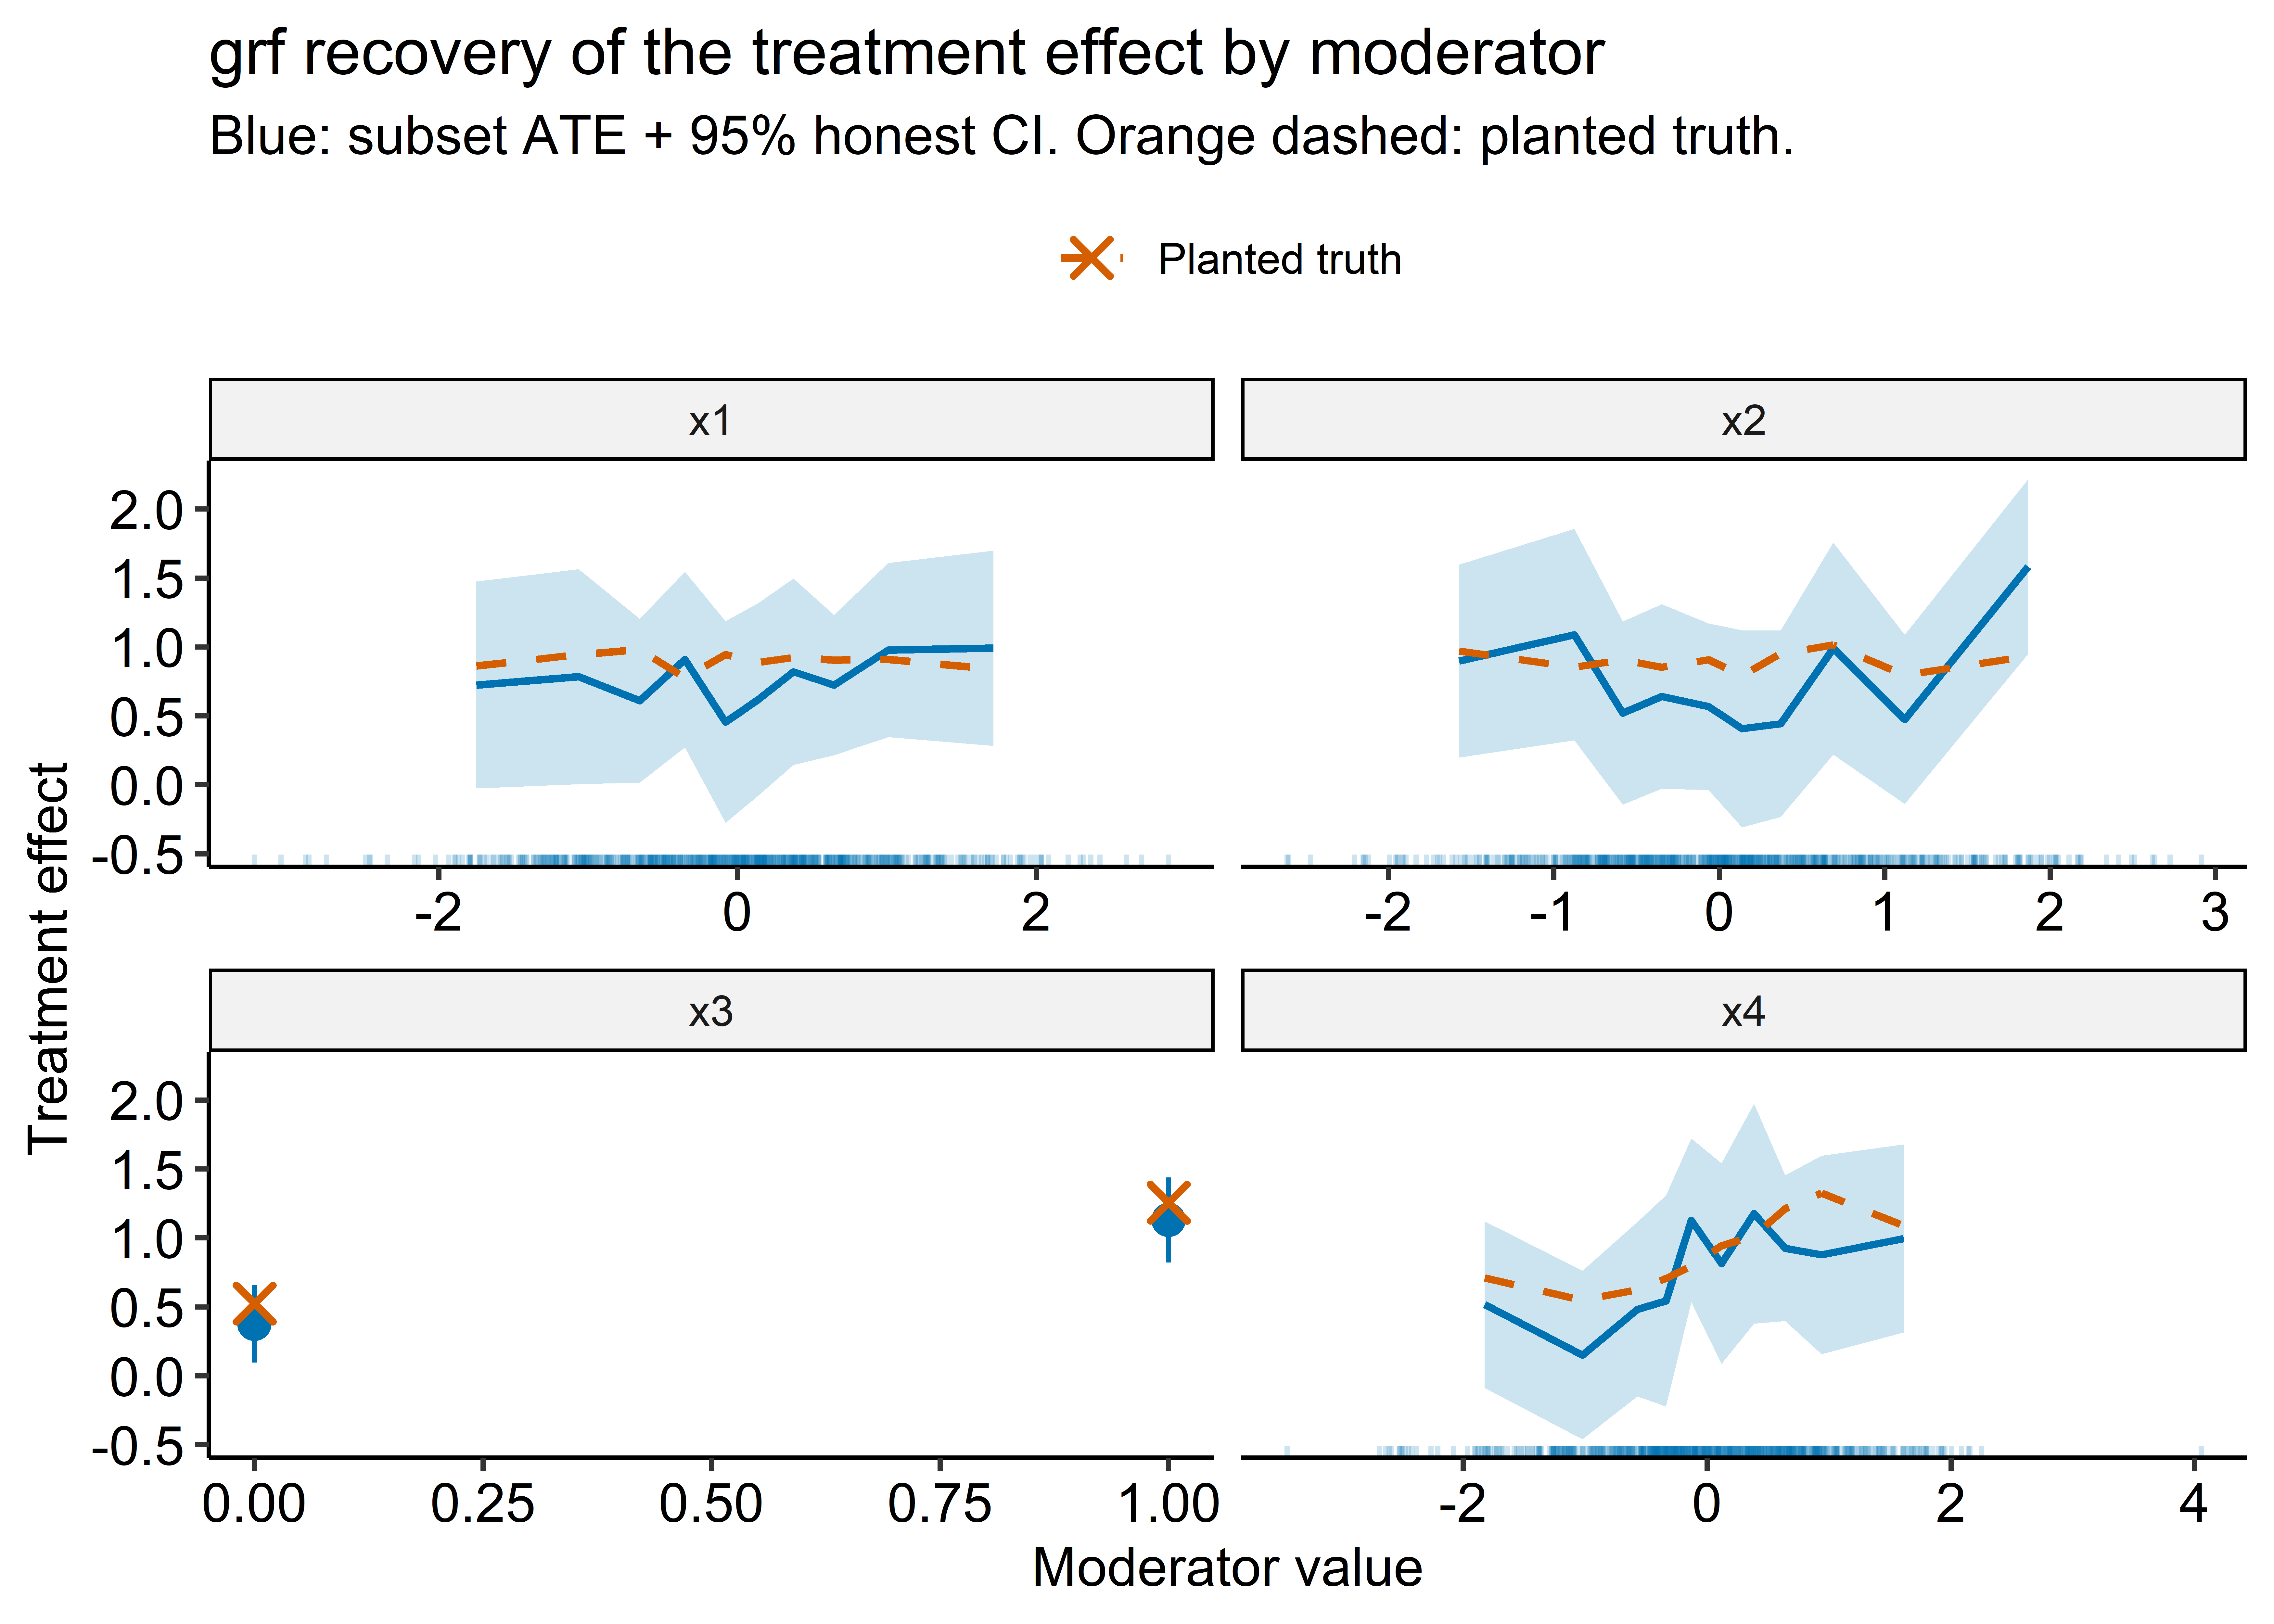

In [ ]:
# map each observation to (covariate, value, bin); x3 binned by its 0/1 level
cov_bins <- tibble(
  obs = seq_len(n),
  x1 = X_mod[, 1],
  x2 = X_mod[, 2],
  x3 = X_mod[, 3],
  x4 = X_mod[, 4]
) |>
  pivot_longer(c(x1, x2, x3, x4), names_to = "covariate", values_to = "value") |>
  mutate(
    bin = if_else(covariate == "x3", value, as.numeric(ntile(value, 10))),
    .by = covariate
  )

# per (covariate, bin): subset ATE with honest cluster-robust CI
cate_by_bin <- cov_bins |>
  distinct(covariate, bin) |>
  pmap(function(covariate, bin) {
    sel <- cov_bins$covariate == covariate & cov_bins$bin == bin
    idx <- cov_bins$obs[sel]
    est <- grf::average_treatment_effect(
      cf,
      target.sample = "all",
      subset = seq_len(n) %in% idx
    )
    tibble(
      covariate = covariate,
      x_pos = mean(cov_bins$value[sel]),
      estimate = unname(est["estimate"]),
      lower = unname(est["estimate"] - 1.96 * est["std.err"]),
      upper = unname(est["estimate"] + 1.96 * est["std.err"]),
      truth = mean(tau_x[idx])
    )
  }) |>
  list_rbind()

cate_cont <- cate_by_bin |> filter(covariate != "x3")
cate_x3 <- cate_by_bin |> filter(covariate == "x3")
rug_cont <- cov_bins |> filter(covariate != "x3")

ggplot(mapping = aes(x = x_pos)) +
  geom_ribbon(
    data = cate_cont,
    aes(ymin = lower, ymax = upper),
    alpha = 0.2,
    fill = "#0072B2"
  ) +
  geom_line(data = cate_cont, aes(y = estimate), colour = "#0072B2", linewidth = 0.8) +
  geom_pointrange(
    data = cate_x3,
    aes(y = estimate, ymin = lower, ymax = upper),
    colour = "#0072B2"
  ) +
  geom_line(
    data = cate_cont,
    aes(y = truth, colour = "Planted truth", linetype = "Planted truth"),
    linewidth = 0.8
  ) +
  geom_point(
    data = cate_x3,
    aes(y = truth, colour = "Planted truth"),
    shape = 4,
    size = 3,
    stroke = 1.2
  ) +
  geom_rug(
    data = rug_cont,
    aes(x = value),
    sides = "b",
    alpha = 0.2,
    colour = "#0072B2",
    inherit.aes = FALSE
  ) +
  scale_colour_manual(values = c("Planted truth" = "#D55E00"), name = NULL) +
  scale_linetype_manual(values = c("Planted truth" = "dashed"), name = NULL) +
  facet_wrap(~covariate, scales = "free_x") +
  labs(
    title = "grf recovery of the treatment effect by moderator",
    subtitle = "Blue: subset ATE + 95% honest CI. Orange dashed: planted truth.",
    x = "Moderator value",
    y = "Treatment effect"
  ) +
  ggpubr::theme_pubr()


# Processing the output downstream

This section shows how the forest output becomes the tidy objects the manuscript consumes. The best linear projection is the headline summary for the BCF/CRF comparison table, so we tidy it into a coefficient frame.

In [ ]:
blp_summary <- blp |>
  unclass() |>
  as.data.frame() |>
  tibble::rownames_to_column("term") |>
  as_tibble() |>
  rename(
    estimate = Estimate,
    std_error = `Std. Error`
  ) |>
  mutate(
    lower = estimate - 1.96 * std_error,
    upper = estimate + 1.96 * std_error
  )

# numeric truth: OLS of true tau on the centred moderators (identical DGP to BCF)
blp_truth <- tibble(
  term = paste0("x", 1:4),
  truth = unname(coef(lm(tau_x ~ scale(X_mod, center = TRUE, scale = FALSE)))[-1])
)

blp_summary


# A tibble: 5 × 7
  term        estimate std_error `t value` `Pr(>|t|)`   lower upper
  <chr>          <dbl>     <dbl>     <dbl>      <dbl>   <dbl> <dbl>
1 (Intercept)   0.363      0.144     2.51    0.0123    0.0797 0.646
2 x1            0.0489     0.117     0.417   0.677    -0.181  0.279
3 x2            0.104      0.111     0.943   0.346    -0.112  0.321
4 x3            0.775      0.220     3.53    0.000447  0.345  1.21 
5 x4            0.179      0.117     1.53    0.127    -0.0508 0.408

The BLP coefficient frame plots as a standard coefficient figure — the same grammar used for the BCF posterior projection, which is what makes the two methods legible side by side in the manuscript. The chunk below is a template following project figure conventions; the manuscript figure will overlay BCF and CRF coefficients on shared axes. Orange crosses mark the numerically computed true projection coefficients: the estimate isolates `x3` near its true `≈ 0.75` and picks up a small positive `x4`, with the two null moderators near zero.

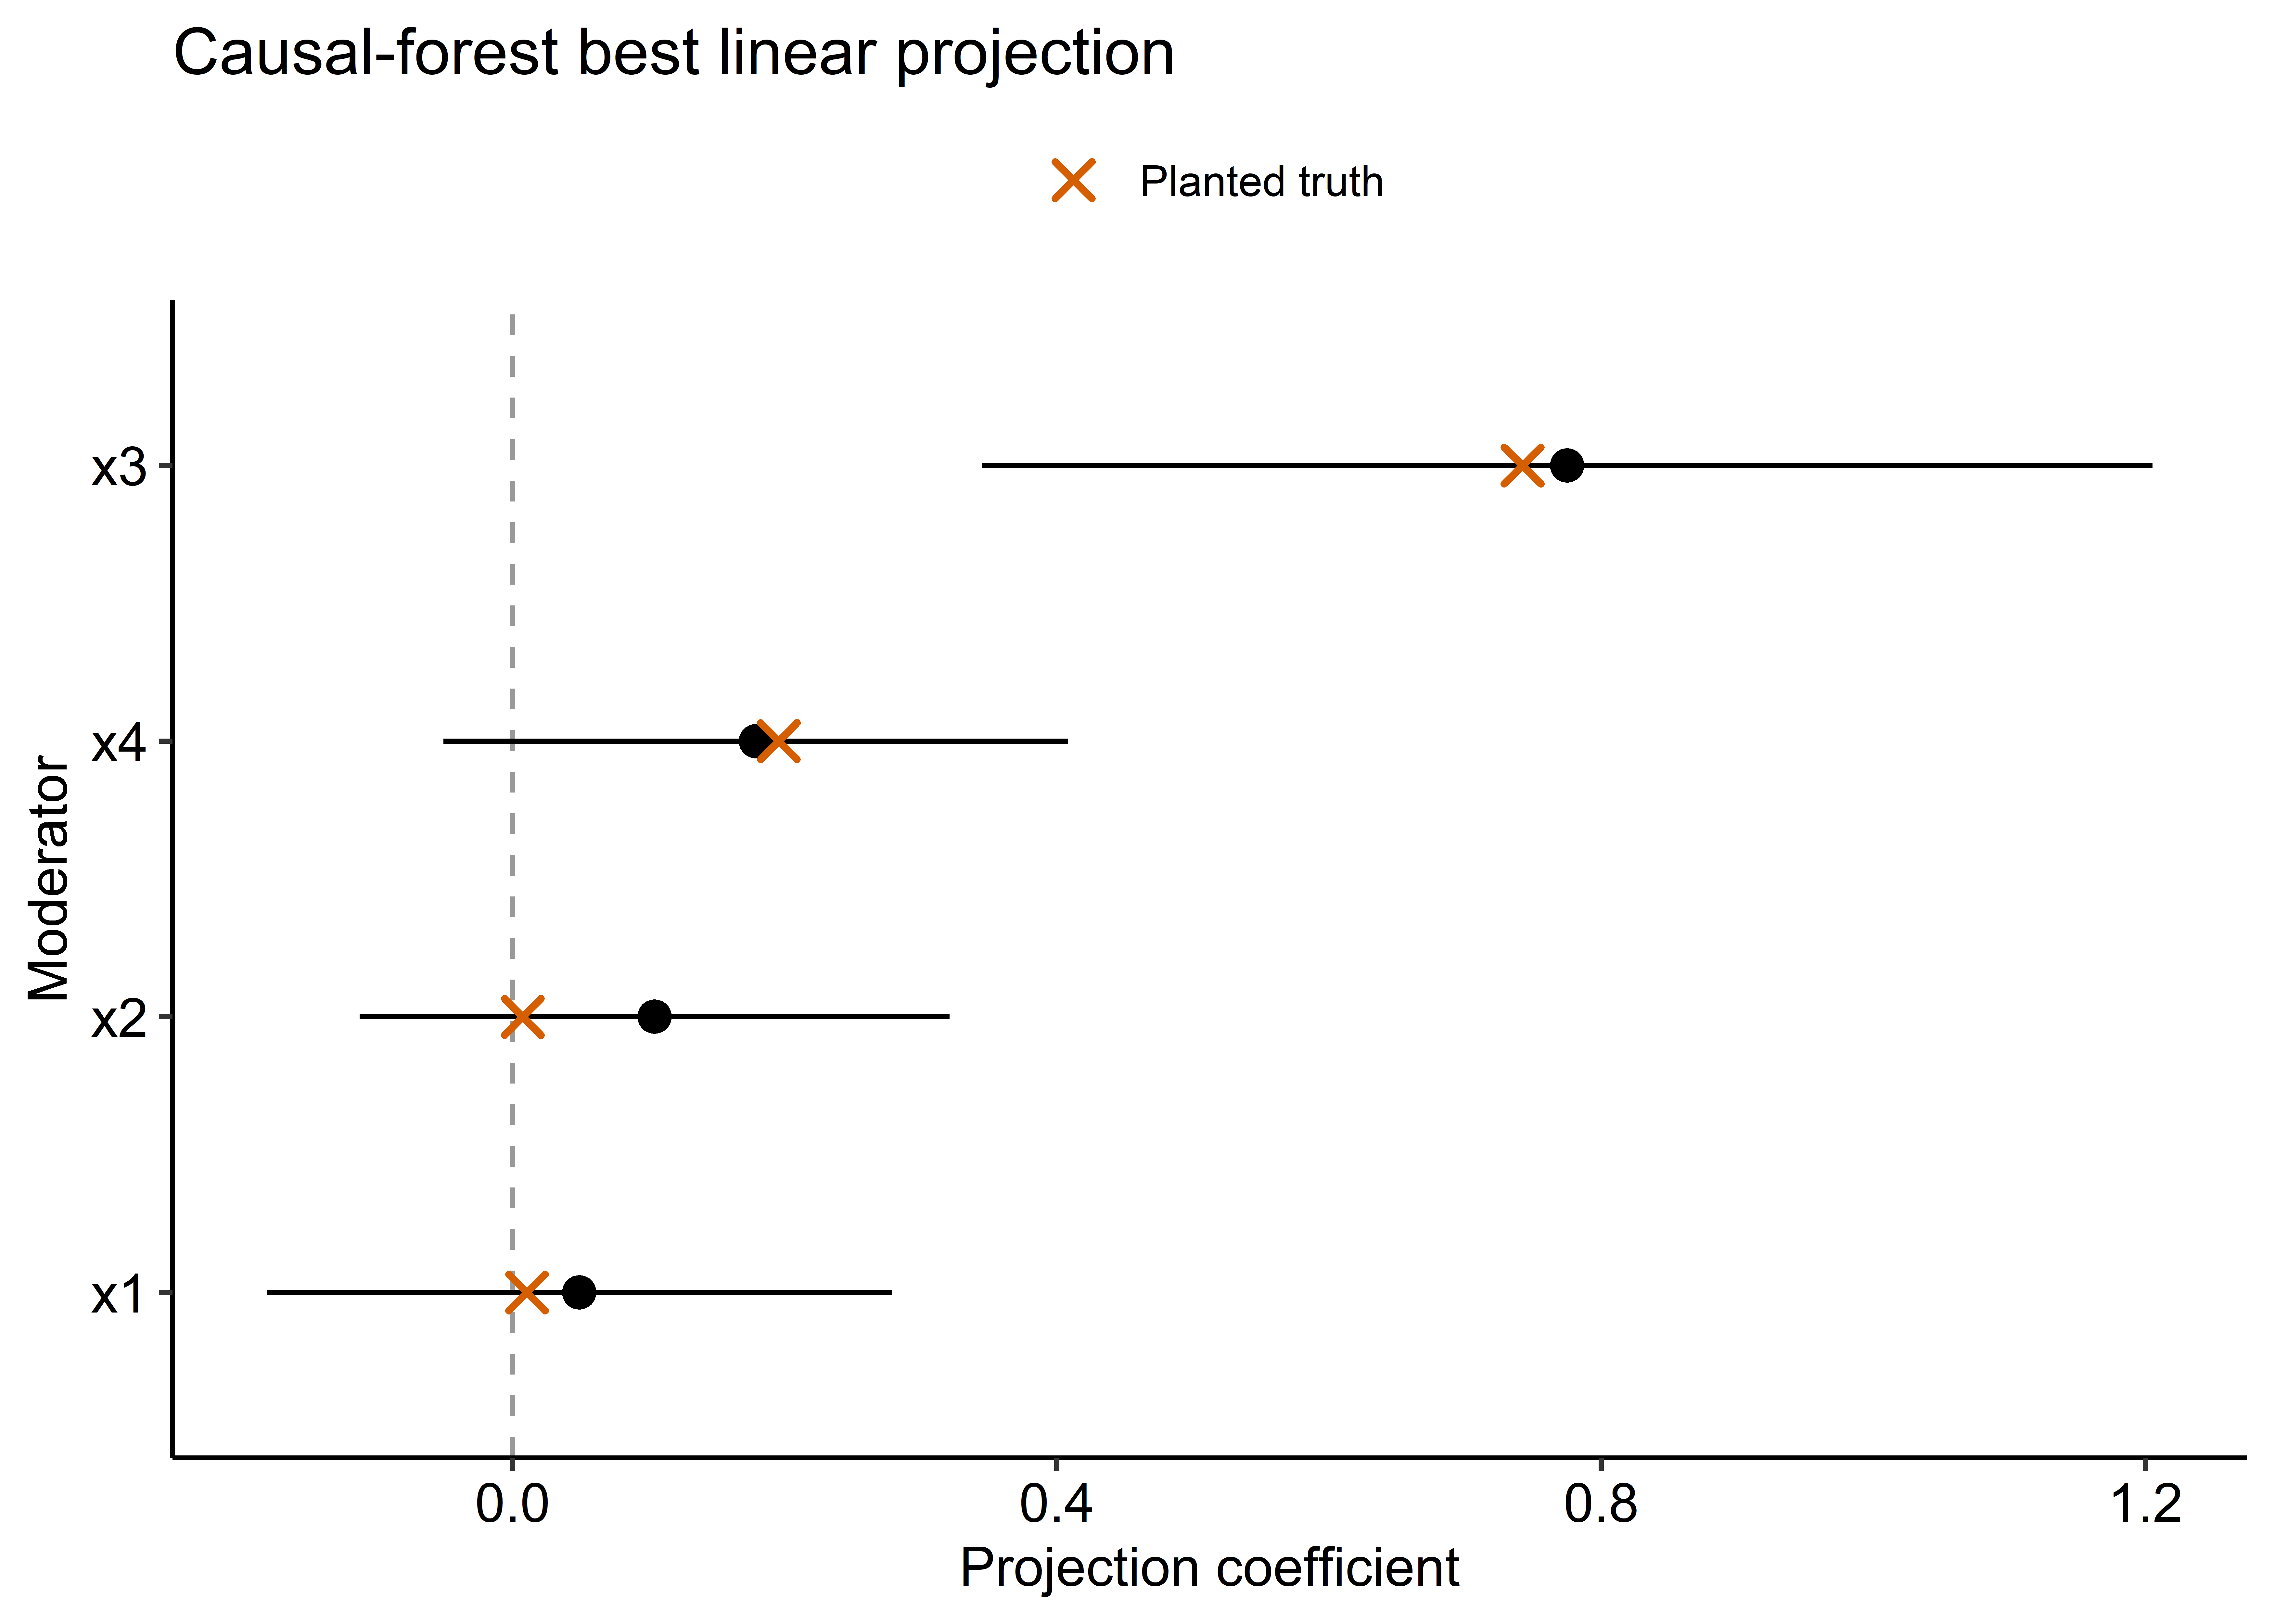

In [ ]:
blp_summary |>
  filter(term != "(Intercept)") |>
  left_join(blp_truth, by = "term") |>
  mutate(term = fct_reorder(term, estimate)) |>
  ggplot(aes(y = term)) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey60") +
  geom_pointrange(aes(x = estimate, xmin = lower, xmax = upper)) +
  geom_point(
    aes(x = truth, colour = "Planted truth"),
    shape = 4,
    size = 3,
    stroke = 1.2
  ) +
  scale_colour_manual(values = c("Planted truth" = "#D55E00"), name = NULL) +
  labs(
    title = "Causal-forest best linear projection",
    x = "Projection coefficient",
    y = "Moderator"
  ) +
  ggpubr::theme_pubr()


# Small-subsample fit on real data

> **Important**
>
> Smoke test only. The prepared long-format tibble now exists at `data/02_processed/eu25_long.rds` (one row = one game round). We confirm the *real* data flows through the same `grf` machinery and record the fit time — **no results are inspected**.

The intent: take a 10,000-row random subset of the dictator game, fit the causal forest with the real moderators, and confirm the *real* data flows through the same machinery before scaling to the full sample.

In [ ]:
dat <- readRDS(here::here("data", "02_processed", "eu25_long.rds"))

set.seed(20260604) # fixed seed
sub <- dat |>
  filter(cj_game_type == "cj_dict") |> # dictator game only
  slice_sample(n = 10000)

y <- sub$cj_pl2
z <- as.integer(sub$cj_rel == "muslim") # Muslim vs all-else pooled
country_id <- factor(sub$meta_country)
respondent_id <- factor(sub$meta_pid)

# moderators: profile-level conjoint attrs + respondent-level pre-treatment items
prof_mods <- c("cj_nationality_shown", "cj_eupos", "cj_age", "cj_sex", "cj_class")
resp_mods <- c(
  "q_gender", "q_age", "q_identity_country", "q_identity_eu",
  "q_identity_europe", "q_religion", "q_class", "q_eu_efficacy_understand",
  "q_pop_reps", "q_pop_goodevil", "q_pop_compromise", "q_dem_compromise",
  "q_dem_listen", "q_tech_experts", "q_tech_leaders", "q_party_harm",
  "q_people_incompetent", "q_eu_longterm", "q_eu_responsive",
  "q_eu_imp_nat_econ", "q_eu_imp_nat_cul", "q_eu_imp_nat_pol",
  "q_eu_abolish", "q_eu_satisfaction", "q_rural_urban", "q_edu_age_stop"
)
mod_df <- sub |>
  select(all_of(c(prof_mods, resp_mods))) |>
  mutate(across(where(is.character), factor))
sub_X <- model.matrix(~ . - 1, data = mod_df) # factors -> dummies

stopifnot(
  nrow(sub_X) == 10000,
  !anyNA(sub_X),
  all(z %in% c(0L, 1L)),
  !anyNA(y)
)


In [ ]:
# country FE dummies + respondent clusters from the real data
country_fe_sub <- fastDummies::dummy_cols(
  data.frame(country = country_id),
  remove_first_dummy = TRUE,
  remove_selected_columns = TRUE
) |>
  as.matrix()
X_sub <- cbind(sub_X, country_fe_sub) # numeric moderators + FE

t0 <- Sys.time()
cf_sub <- grf::causal_forest(
  X = X_sub,
  Y = y,
  W = z,
  W.hat = 0.5, # known conjoint propensity
  clusters = as.integer(respondent_id),
  num.trees = 2000,
  seed = 20260604
)
fit_secs <- as.numeric(Sys.time() - t0, units = "secs")

ate_sub <- grf::average_treatment_effect(cf_sub, target.sample = "all") # extractors run
blp_sub <- grf::best_linear_projection(cf_sub, sub_X)

# full-sample cost extrapolation
n_full <- sum(dat$cj_game_type == "cj_dict")
cat(sprintf("CF subsample fit: %.1f s (n = %d).\n", fit_secs, length(y)))


CF subsample fit: 6.6 s (n = 10000).

Full dictator (n = 84603) ~55.5 s (~linear in n). grf clusters cheaply, so CF is the lighter of the two methods; the BCF nested-RE fit is the binding constraint on the project window.

# Session Info

In [ ]:
session_info()


─ Session info ───────────────────────────────────────────────────────────────
 setting  value
 version  R version 4.5.3 (2026-03-11 ucrt)
 os       Windows 11 x64 (build 26200)
 system   x86_64, mingw32
 ui       RTerm
 language (EN)
 collate  English_United States.utf8
 ctype    English_United States.utf8
 tz       Europe/Berlin
 date     2026-06-12
 pandoc   3.8.3 @ c:\\Program Files\\Positron\\resources\\app\\quarto\\bin\\tools/ (via rmarkdown)
 quarto   1.9.36 @ C:\\PROGRA~1\\Quarto\\bin\\quarto.exe

─ Packages ───────────────────────────────────────────────────────────────────
 package      * version    date (UTC) lib source
 abind          1.4-8      2024-09-12 [1] CRAN (R 4.5.0)
 backports      1.5.0      2024-05-23 [1] CRAN (R 4.5.0)
 broom          1.0.11     2025-12-04 [1] CRAN (R 4.5.2)
 car            3.1-3      2024-09-27 [1] CRAN (R 4.5.1)
 carData        3.0-5      2022-01-06 [1] CRAN (R 4.5.1)
 cli            3.6.5      2025-04-23 [1] CRAN (R 4.5.1)
 codetools      0.2

# Execution Time

In [ ]:
end_time <- Sys.time()
exec_time <- end_time - start_time
cat(paste(
  "R code execution time:",
  round(as.numeric(exec_time, units = "secs"), 2),
  "seconds."
))


R code execution time: 118.94 seconds.

```` markdown
---
subtitle: |
  Nested Structure in `grf` Causal Forests — Mechanism Test
date: last-modified
date-format: MMMM D, YYYY
format:
  html:
    toc: true
    toc-depth: 3
    code-fold: true
    code-tools: true
execute:
  echo: true
  warning: true
  eval: true
  message: true
---

# Purpose {#sec-purpose}

This notebook is a **scaffold**, not a finished analysis.
It is the `grf` counterpart to `03_multibart_nested_ri_test.qmd`: where that notebook tests the hierarchical-BCF primary method, this one tests the **Causal Random Forest robustness strategy** on the same synthetic data so the two are directly comparable.

The goals, in priority order, are:

1. **Verify the proposed `grf` strategy works in principle.**
   On *synthetic* two-level data with known effects we confirm that `grf::causal_forest()` with country fixed effects in `X`, respondent-level `clusters`, and the known conjoint propensity recovers the planted average and heterogeneous treatment effects.
2. **See what the output looks like and how to process it downstream.**
   We walk the forest output through the headline quantities the manuscript needs — cluster-robust ATE, individual `τ̂(x)`, and the best linear projection onto the pre-specified moderators — and produce the same true-vs-recovered figure as the BCF test.

::: callout-note
## How `grf` handles the nesting

The data are observations nested in respondents nested in countries.
The robustness strategy accounts for both levels without random effects:

- **Country** enters as **fixed effects** — one-hot dummy columns appended to the covariate matrix `X`. `grf` requires a numeric `X`, so we encode the factor explicitly rather than passing it raw.
- **Respondent** enters through `clusters = respondent_id`. This gives honest, cluster-aware subsampling (whole respondents are held out together) and cluster-robust variance for the ATE, absorbing the within-person dependence across the three conjoint tasks.

This is the frequentist analogue of the BCF random-intercept specification: the same nuisance structure, addressed by FE + clustering instead of partial pooling.
:::

::: callout-note
## Cost is not the concern here

Unlike the dense `WtW` solve in the nested-RE BCF fit, `grf` scales comfortably to the full ~112,500 observations and ~37,500 respondent clusters.
The synthetic check below is about **correctness of the strategy**, not feasibility; the small dimensions just keep the smoke test fast.
:::

# Setup {#sec-setup}

quarto-executable-code-5450563D

```r
#| label: setup
#| include: false
# execution time
start_time <- Sys.time()
# console width
options(width = 80)
# packages
p_required <- c(
  "tidyverse", # dplyr, ggplot2, tidyr
  "here", # relative paths
  "ggpubr", # theme_pubr
  "patchwork", # multi-panel figure
  "fastDummies", # country fixed-effect dummies
  "grf", # causal_forest robustness method
  "sessioninfo" # session docs
)
packages <- rownames(installed.packages())
p_to_install <- p_required[!(p_required %in% packages)]
if (length(p_to_install) > 0) {
  install.packages(p_to_install)
}
sapply(p_required, require, character.only = TRUE)
rm(p_required, p_to_install, packages)
```

# Synthetic mechanism check {#sec-synthetic}

This is the primary test.
We reuse the **exact data-generating process** from the BCF notebook (same seed), so the two methods are tested on identical data and their recovered effects can be compared one-to-one.

## Simulate two-level data {#sec-simulate}

Respondents nested in countries, three conjoint tasks each, treatment randomized at the known conjoint propensity of 0.5.
The country and respondent intercepts are pure nuisance for `grf` — country absorbed by fixed effects, respondent by clustering — so unlike the BCF test their variances are not quantities we recover.
The treatment effect is a clean `0.75` contrast on the binary `x3` plus a mean-zero nonlinear (sine) effect of the continuous `x4`, so a correct fit recovers heterogeneity, not just an average.
Per-quantity detail is in the chunk comments.

quarto-executable-code-5450563D

```r
#| label: simulate
set.seed(20260602)

# dimensions: 8 countries x 25 respondents x 3 tasks = 600 rows
n_country <- 8
n_resp_per_country <- 25
n_task <- 3

# nested ids; respondent ids are globally unique, so each sits in one country
country_id <- factor(rep(
  seq_len(n_country),
  each = n_resp_per_country * n_task
))
resp_id <- factor(rep(seq_len(n_country * n_resp_per_country), each = n_task))
n <- length(resp_id)

# planted variance components, country spread >> respondent spread (nuisance)
sigma_country <- 1.5
sigma_resp <- 0.5
# per-country and per-respondent baseline shifts: FE + clusters absorb these
b_country <- rnorm(n_country, 0, sigma_country)
b_resp <- rnorm(nlevels(resp_id), 0, sigma_resp)

# candidate moderators x1-x4 (country dummies added later)
p <- 4
X_mod <- matrix(rnorm(n * p), nrow = n)
colnames(X_mod) <- paste0("x", seq_len(p))
# x3: binary dummy, a randomized binary conjoint-attribute stand-in
X_mod[, 3] <- rbinom(n, 1, 0.5)
# prognostic (control) surface: linear in x1/x2, flat in x3/x4; partialled out
mu_x <- 1.0 * X_mod[, 1] - 0.5 * X_mod[, 2]
# x4: mean-zero nonlinear (sine) moderator
g_x4 <- 0.4 * sin(1.5 * X_mod[, 4])
# heterogeneous effect: x3 binary contrast (0.75) + x4 sine (average ~0.875)
tau_x <- 0.5 + 0.75 * X_mod[, 3] + g_x4

# randomized treatment, known propensity 0.5
z <- rbinom(n, 1, 0.5)

# linear predictor: prognostic + effect-on-treated + nested intercepts (mu only)
lin_pred <- mu_x +
  tau_x * z +
  b_country[as.integer(country_id)] +
  b_resp[as.integer(resp_id)]

# continuous outcome: linear predictor + residual noise (SD 1)
y <- lin_pred + rnorm(n, 0, 1)
```

A `stopifnot()` guards the nesting invariant — every respondent sits in exactly one country — and the basic dimensions.

quarto-executable-code-5450563D

```r
#| label: check-sim
# each respondent maps to exactly one country
resp_country_map <- tapply(as.integer(country_id), resp_id, function(v) {
  length(unique(v))
})
stopifnot(
  all(resp_country_map == 1),
  length(y) == n,
  nrow(X_mod) == n,
  all(sort(unique(z)) == c(0, 1)),
  all(X_mod[, 3] %in% c(0, 1)), # x3 is a binary dummy
  is.numeric(X_mod[, 4]), # x4 stays continuous
  !anyNA(tau_x),
  abs(mean(g_x4)) < 0.05 # x4 sine is mean-zero: ATE preserved
)
```

## Planted truth by moderator {#sec-planted-truth}

Before fitting, this figure shows the planted truth directly: the true per-observation treatment effect against each candidate moderator.
It is the same DGP and figure as the BCF notebook, so the two recovery checks are read against an identical truth.
The two null moderators `x1` and `x2` should read flat; the binary `x3` should show a clean two-level jump of about `0.75`; the continuous `x4` should trace a mean-zero sine.
Continuous panels show alpha-blended individual truths with a ten-bin mean curve and a covariate rug; the binary `x3` panel shows its two level means.
The common y-axis lets the flat nulls be read against the active moderators at a glance.

quarto-executable-code-5450563D

```r
#| label: fig-truth-cont
#| fig-cap: "Planted truth (synthetic data): true per-observation treatment effect tau(x) against each candidate moderator. Continuous panels (x1, x2, x4) show alpha-blended individual truths, a 10-quantile-bin mean curve, and a covariate rug; the binary x3 panel shows its two level means. Nulls (x1, x2) flat; x3 a clean ~0.75 contrast; x4 a mean-zero sine."
#| dpi: 500
# long form: each moderator's value against the true tau_i
truth_long <- tibble(
  x1 = X_mod[, 1],
  x2 = X_mod[, 2],
  x3 = X_mod[, 3],
  x4 = X_mod[, 4],
  tau = tau_x
) |>
  pivot_longer(c(x1, x2, x3, x4), names_to = "covariate", values_to = "value")

# continuous covariates: raw points + 10-quantile binned-mean curve
truth_cont <- truth_long |> filter(covariate != "x3")
truth_cont_bin <- truth_cont |>
  mutate(bin = ntile(value, 10), .by = covariate) |>
  summarise(value = mean(value), tau = mean(tau), .by = c(covariate, bin))

# binary x3: the two level means at 0 and 1
truth_x3 <- truth_long |>
  filter(covariate == "x3") |>
  summarise(tau = mean(tau), .by = c(covariate, value))

ggplot(mapping = aes(x = value, y = tau)) +
  geom_point(data = truth_cont, alpha = 0.15, colour = "#0072B2") +
  geom_rug(data = truth_cont, sides = "b", alpha = 0.3, colour = "#0072B2") +
  geom_line(data = truth_cont_bin, colour = "#0072B2", linewidth = 0.8) +
  geom_point(data = truth_x3, size = 3, colour = "#0072B2") +
  facet_wrap(~covariate, scales = "free_x") +
  labs(
    title = "Planted truth: true treatment effect by moderator",
    x = "Moderator value",
    y = "True treatment effect"
  ) +
  ggpubr::theme_pubr()
```

## Build covariates and clustering {#sec-build}

Two pieces encode the nesting.
Country fixed effects become one-hot dummy columns (one dropped to avoid collinearity with the intercept `grf` fits internally) appended to the moderator matrix.
Respondent ids become an integer cluster vector.
We assert the assembled `X` has the expected width (`p` moderators + `C − 1` country dummies) and that the cluster vector is the right length.

quarto-executable-code-5450563D

```r
#| label: build
# country fixed effects as dummy columns
country_fe <- fastDummies::dummy_cols(
  data.frame(country = country_id),
  remove_first_dummy = TRUE,
  remove_selected_columns = TRUE
) |>
  as.matrix()

# moderators + country FE
X <- cbind(X_mod, country_fe)

# respondent-level clusters
clusters <- as.integer(resp_id)

stopifnot(
  nrow(X) == n,
  ncol(X) == p + (n_country - 1),
  length(clusters) == n,
  dplyr::n_distinct(clusters) == n_country * n_resp_per_country
)
```

## Fit the causal forest {#sec-fit}

`causal_forest()` takes the numeric `X`, outcome `y`, and treatment `z`.
Every argument in the call below:

- **`X`** — the numeric covariate matrix: the `p` moderators plus the `C − 1` country fixed-effect dummies assembled in @sec-build. `grf` requires a numeric matrix, which is why country was one-hot encoded rather than passed as a factor.
- **`Y`** — the outcome vector.
- **`W`** — the treatment (here binary 0/1, but `grf` also accepts continuous treatments).
- **`W.hat`** — the propensity `E(W | X)`. Passing the scalar `0.5` fixes it at the known conjoint propensity for every observation, so `grf` skips its internal propensity regression (the analogue of passing known `zhat`/`pihat` to BCF). Left `NULL`, `grf` would estimate it with a regression forest.
- **`clusters`** — an integer vector assigning each row to a respondent. This switches on cluster-aware *honest* subsampling (whole respondents are held out together, never split across the sample-fitting and estimation halves) and the cluster-robust variance that feeds the ATE standard error. It is how the within-person dependence across the three tasks is absorbed.
- **`num.trees`** — number of trees in the forest. More trees give more stable estimates and tighter variance estimation; `2000` is a smoke-test value, comfortably below a production setting.
- **`seed`** — RNG seed for reproducible subsampling and tree construction.

Two defaults left implicit are worth knowing:

- **`Y.hat = NULL`** (not passed) means `grf` fits its own regression forest of `Y` on `X` (which includes the country FE) and partials it out — the orthogonalization step at the heart of the R-learner. This is how the prognostic surface and country baselines are removed before estimating `tau(x)`.
- **`honesty = TRUE`** (the package default) splits each tree's data so the structure is learned on one half and the leaf effects estimated on the other, which is what makes the confidence intervals valid.

::: callout-note
## What prints to the console while it runs

Unlike the BCF sampler, `grf` is **silent** during fitting — there is no per-iteration trace, and a successful fit prints nothing at all.
That absence is normal, not a sign the call hung.
What you may see instead are *warnings*, and they are worth reading:

- a warning that the number of trees is too small for reliable variance estimates (raise `num.trees`);
- a warning about clusters being unbalanced or fewer clusters than expected (a sign the `clusters` vector was built wrong).

For a readable summary of the fitted object, call `print(cf)`, which reports the forest type, the number of trees, and the number of training samples and clusters — the quickest confirmation that the nesting was passed in as intended.
The substantive diagnostics all come *after* the fit, from the functions called in @sec-extract.
:::

quarto-executable-code-5450563D

```r
#| label: fit
cf <- grf::causal_forest(
  X = X,
  Y = y,
  W = z,
  W.hat = 0.5, # known conjoint propensity
  clusters = clusters, # respondent-level honest sampling + robust variance
  num.trees = 2000,
  seed = 20260602
)
```

## What the fitted object contains {#sec-fit-object}

`causal_forest()` returns a list of class `causal_forest`.
Unlike the BCF object, the treatment-effect estimates are already sitting on it — no forest needs to be replayed.
The components worth knowing:

- **`$predictions`** — a length-`n` vector of *out-of-bag* estimates of `tau(x)` for the training rows (each row predicted only by trees that did not see it, which is what keeps them honest). `predict(cf)` with no new data returns the same OOB predictions wrapped in a data frame.
- **`$variance.estimates`** — per-observation variance of those predictions (populated because the default `ci.group.size` is greater than 1); the basis for individual confidence intervals.
- **`$X.orig`, `$Y.orig`, `$W.orig`** — the data as passed in.
- **`$Y.hat`, `$W.hat`** — the fitted nuisance estimates that were partialled out: here `$W.hat` is the constant `0.5` we supplied, and `$Y.hat` is the internal regression-forest fit of `Y` on `X`.
- **`$clusters`** — the cluster assignment actually used, retained so downstream functions reproduce the cluster-robust variance.
- **`$tunable.params`, `$num.trees`** — the settings the forest was grown with.

The three headline quantities are read off with dedicated functions rather than from slots directly:

- **`predict(cf)$predictions`** — the individual `tau_hat`, as above.
- **`average_treatment_effect(cf, target.sample = "all")`** — a named numeric vector with `estimate` and `std.err` (the cluster-robust SE), i.e. the ATE.
- **`best_linear_projection(cf, X_mod)`** — a coefficient table (an `lmtest::coeftest` matrix) with one row per moderator plus an intercept and columns `Estimate`, `Std. Error`, `t value`, `Pr(>|t|)`. It is the linear summary of how `tau(x)` moves with each pre-specified moderator, and the direct counterpart to the BCF posterior projection.

## Extract and verify {#sec-extract}

::: callout-note
## The planted truth we are checking against

From @sec-simulate, the data-generating values the quantities below should reproduce:

- **$\tau(x)$** — a binary $0.75$ contrast on $x_3$ ($0.5$ at $x_3 = 0$, $1.25$ at $x_3 = 1$) plus a mean-zero sine in $x_4$. Population average $\approx 0.875$, which is what the cluster-robust ATE targets.
- **Best linear projection** — read off the planted $\tau$ as its OLS projection onto the centred moderators $[x_1\ x_2\ x_3\ x_4]$: $\approx 0.75$ on $x_3$, a small positive slope on $x_4$ (the linear part of the sine), and $\approx 0$ on $x_1$, $x_2$. The BLP should isolate $x_3$ near $0.75$ and pick up a faint positive $x_4$.
- **Nuisance** — `grf` does not report the prognostic surface $\mu(x)$ or the country/respondent variance components; those enter only as fixed effects and clusters and are partialled out, so there is no separate recovery check for them (unlike the BCF notebook).
:::

We pull the three headline quantities.
The cluster-robust ATE should land near the planted average effect `mean(tau_x)`; the individual predictions should correlate with the true `τ(x)` and separate in the right direction across the binary `x3` moderator; the best linear projection onto the moderators should flag `x3` as the one with a clearly non-zero slope, near its value above.

quarto-executable-code-5450563D

```r
#| label: extract
# cluster-robust average treatment effect
ate <- grf::average_treatment_effect(cf, target.sample = "all")

# individual treatment effects
tau_hat <- predict(cf)$predictions

# best linear projection onto the pre-specified moderators
blp <- grf::best_linear_projection(cf, X_mod)

cat("planted ATE:", round(mean(tau_x), 3), "\n")
cat(
  "recovered ATE:",
  round(ate["estimate"], 3),
  "(SE",
  round(ate["std.err"], 3),
  ")\n"
)
cat("cor(true tau, tau_hat):", round(cor(tau_x, tau_hat), 3), "\n")
cat(
  "tau_hat mean  x3<=0 / x3>0:",
  round(mean(tau_hat[X_mod[, 3] <= 0]), 3),
  "/",
  round(mean(tau_hat[X_mod[, 3] > 0]), 3),
  "\n"
)

# the two moderator groups should separate in the right direction
stopifnot(
  mean(tau_hat[X_mod[, 3] > 0]) > mean(tau_hat[X_mod[, 3] <= 0]),
  length(tau_hat) == n
)

print(round(blp[, 1:2], 3))
```

If the recovered ATE is within a couple of standard errors of the planted average, `τ̂(x)` orders correctly across `x3`, and the BLP isolates `x3`, the strategy is working as intended.
Exact recovery is not expected from a smoke-test forest on a small sample; partial pooling toward the grand mean (here, regularization toward the ATE) is expected.

## True vs. recovered covariate effects {#sec-recovery}

The analogue of the BCF notebook's recovery figure.
`grf` targets `τ(x)` directly and does not return a separate prognostic surface, so the figure focuses on the treatment effect.
We plot recovered against true `τ(x)` with a dashed 45° identity line, colouring points by the binary `x3` group: each group fans out along the true axis because the `x4` sine adds within-group spread, and the points should track the identity, shrunk gently toward the centre.

quarto-executable-code-5450563D

```r
#| label: recover-effects
recovery <- tibble(
  truth = tau_x,
  estimate = tau_hat,
  moderator = if_else(X_mod[, 3] == 1, "x3 = 1", "x3 = 0")
)
```

quarto-executable-code-5450563D

```r
#| label: fig-recovery-grf
#| fig-cap: "True (data-generating) treatment effect tau(x) vs. recovered causal-forest estimates on synthetic data, coloured by the true moderator group. Dashed line is the 45° identity; points are individual observations. Smoke-test fit, small sample."
#| dpi: 500
recovery |>
  ggplot(aes(x = truth, y = estimate, colour = moderator)) +
  geom_abline(
    slope = 1,
    intercept = 0,
    linetype = "dashed",
    colour = "grey50"
  ) +
  geom_point(alpha = 0.3) +
  scale_colour_manual(values = c("x3 = 0" = "#0072B2", "x3 = 1" = "#D55E00")) +
  labs(
    title = "True vs. recovered treatment effect (synthetic smoke test)",
    subtitle = "Dashed line: 45° identity (perfect recovery)",
    x = "True effect",
    y = "Causal-forest estimate",
    colour = NULL
  ) +
  ggpubr::theme_pubr()
```

## CATE recovery by covariate {#sec-cate-by-cov}

This is the `grf` counterpart to the BCF recovery figure: the same bins and levels, but built from causal-forest point estimates with honest cluster-robust confidence intervals rather than a posterior.
For each bin we compute the subset ATE with `average_treatment_effect()` and form a 95% interval as estimate $\pm\,1.96\times\text{SE}$.
Continuous moderators use ten shared quantile bins; the binary `x3` uses its two levels.
The null moderators `x1` and `x2` should sit flat near the ATE, `x3` should show a clean two-level jump of about `0.75`, and `x4` should trace the sine.
The planted binned truth (orange, dashed) is overlaid on bins identical to the BCF figure, so the two methods are read side by side.

quarto-executable-code-5450563D

```r
#| label: fig-cate-by-cov-grf
#| fig-cap: "grf recovery of the treatment-effect surface by moderator (synthetic data). Per bin (10 quantile bins for continuous x1/x2/x4; the two levels for binary x3) the subset ATE is computed with honest cluster-robust CIs (estimate ± 1.96 SE); blue shows the estimate, orange-dashed the planted binned truth. Nulls flat near the ATE; x3 a clean ~0.75 jump; x4 the sine. Same bins as the BCF figure."
#| dpi: 500
# map each observation to (covariate, value, bin); x3 binned by its 0/1 level
cov_bins <- tibble(
  obs = seq_len(n),
  x1 = X_mod[, 1],
  x2 = X_mod[, 2],
  x3 = X_mod[, 3],
  x4 = X_mod[, 4]
) |>
  pivot_longer(c(x1, x2, x3, x4), names_to = "covariate", values_to = "value") |>
  mutate(
    bin = if_else(covariate == "x3", value, as.numeric(ntile(value, 10))),
    .by = covariate
  )

# per (covariate, bin): subset ATE with honest cluster-robust CI
cate_by_bin <- cov_bins |>
  distinct(covariate, bin) |>
  pmap(function(covariate, bin) {
    sel <- cov_bins$covariate == covariate & cov_bins$bin == bin
    idx <- cov_bins$obs[sel]
    est <- grf::average_treatment_effect(
      cf,
      target.sample = "all",
      subset = seq_len(n) %in% idx
    )
    tibble(
      covariate = covariate,
      x_pos = mean(cov_bins$value[sel]),
      estimate = unname(est["estimate"]),
      lower = unname(est["estimate"] - 1.96 * est["std.err"]),
      upper = unname(est["estimate"] + 1.96 * est["std.err"]),
      truth = mean(tau_x[idx])
    )
  }) |>
  list_rbind()

cate_cont <- cate_by_bin |> filter(covariate != "x3")
cate_x3 <- cate_by_bin |> filter(covariate == "x3")
rug_cont <- cov_bins |> filter(covariate != "x3")

ggplot(mapping = aes(x = x_pos)) +
  geom_ribbon(
    data = cate_cont,
    aes(ymin = lower, ymax = upper),
    alpha = 0.2,
    fill = "#0072B2"
  ) +
  geom_line(data = cate_cont, aes(y = estimate), colour = "#0072B2", linewidth = 0.8) +
  geom_pointrange(
    data = cate_x3,
    aes(y = estimate, ymin = lower, ymax = upper),
    colour = "#0072B2"
  ) +
  geom_line(
    data = cate_cont,
    aes(y = truth, colour = "Planted truth", linetype = "Planted truth"),
    linewidth = 0.8
  ) +
  geom_point(
    data = cate_x3,
    aes(y = truth, colour = "Planted truth"),
    shape = 4,
    size = 3,
    stroke = 1.2
  ) +
  geom_rug(
    data = rug_cont,
    aes(x = value),
    sides = "b",
    alpha = 0.2,
    colour = "#0072B2",
    inherit.aes = FALSE
  ) +
  scale_colour_manual(values = c("Planted truth" = "#D55E00"), name = NULL) +
  scale_linetype_manual(values = c("Planted truth" = "dashed"), name = NULL) +
  facet_wrap(~covariate, scales = "free_x") +
  labs(
    title = "grf recovery of the treatment effect by moderator",
    subtitle = "Blue: subset ATE + 95% honest CI. Orange dashed: planted truth.",
    x = "Moderator value",
    y = "Treatment effect"
  ) +
  ggpubr::theme_pubr()
```

# Processing the output downstream {#sec-downstream}

This section shows how the forest output becomes the tidy objects the manuscript consumes.
The best linear projection is the headline summary for the BCF/CRF comparison table, so we tidy it into a coefficient frame.

quarto-executable-code-5450563D

```r
#| label: tidy-blp
blp_summary <- blp |>
  unclass() |>
  as.data.frame() |>
  tibble::rownames_to_column("term") |>
  as_tibble() |>
  rename(
    estimate = Estimate,
    std_error = `Std. Error`
  ) |>
  mutate(
    lower = estimate - 1.96 * std_error,
    upper = estimate + 1.96 * std_error
  )

# numeric truth: OLS of true tau on the centred moderators (identical DGP to BCF)
blp_truth <- tibble(
  term = paste0("x", 1:4),
  truth = unname(coef(lm(tau_x ~ scale(X_mod, center = TRUE, scale = FALSE)))[-1])
)

blp_summary
```

The BLP coefficient frame plots as a standard coefficient figure — the same grammar used for the BCF posterior projection, which is what makes the two methods legible side by side in the manuscript.
The chunk below is a template following project figure conventions; the manuscript figure will overlay BCF and CRF coefficients on shared axes.
Orange crosses mark the numerically computed true projection coefficients: the estimate isolates `x3` near its true `≈ 0.75` and picks up a small positive `x4`, with the two null moderators near zero.

quarto-executable-code-5450563D

```r
#| label: fig-blp
#| fig-cap: "Best linear projection of the causal forest onto the pre-specified moderators (synthetic data), with 95% confidence intervals. Orange crosses mark the numerically computed true projection coefficients (x3 ≈ 0.75, small positive x4, x1/x2 ≈ 0). Template for the BCF/CRF comparison figure."
#| dpi: 500
blp_summary |>
  filter(term != "(Intercept)") |>
  left_join(blp_truth, by = "term") |>
  mutate(term = fct_reorder(term, estimate)) |>
  ggplot(aes(y = term)) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey60") +
  geom_pointrange(aes(x = estimate, xmin = lower, xmax = upper)) +
  geom_point(
    aes(x = truth, colour = "Planted truth"),
    shape = 4,
    size = 3,
    stroke = 1.2
  ) +
  scale_colour_manual(values = c("Planted truth" = "#D55E00"), name = NULL) +
  labs(
    title = "Causal-forest best linear projection",
    x = "Projection coefficient",
    y = "Moderator"
  ) +
  ggpubr::theme_pubr()
```

# Small-subsample fit on real data {#sec-subsample}

::: callout-important
Smoke test only.
The prepared long-format tibble now exists at `data/02_processed/eu25_long.rds` (one row = one game round).
We confirm the *real* data flows through the same `grf` machinery and record the fit time — **no results are inspected**.
:::

The intent: take a 10,000-row random subset of the dictator game, fit the causal forest with the real moderators, and confirm the *real* data flows through the same machinery before scaling to the full sample.

quarto-executable-code-5450563D

```r
#| label: load-subsample
dat <- readRDS(here::here("data", "02_processed", "eu25_long.rds"))

set.seed(20260604) # fixed seed
sub <- dat |>
  filter(cj_game_type == "cj_dict") |> # dictator game only
  slice_sample(n = 10000)

y <- sub$cj_pl2
z <- as.integer(sub$cj_rel == "muslim") # Muslim vs all-else pooled
country_id <- factor(sub$meta_country)
respondent_id <- factor(sub$meta_pid)

# moderators: profile-level conjoint attrs + respondent-level pre-treatment items
prof_mods <- c("cj_nationality_shown", "cj_eupos", "cj_age", "cj_sex", "cj_class")
resp_mods <- c(
  "q_gender", "q_age", "q_identity_country", "q_identity_eu",
  "q_identity_europe", "q_religion", "q_class", "q_eu_efficacy_understand",
  "q_pop_reps", "q_pop_goodevil", "q_pop_compromise", "q_dem_compromise",
  "q_dem_listen", "q_tech_experts", "q_tech_leaders", "q_party_harm",
  "q_people_incompetent", "q_eu_longterm", "q_eu_responsive",
  "q_eu_imp_nat_econ", "q_eu_imp_nat_cul", "q_eu_imp_nat_pol",
  "q_eu_abolish", "q_eu_satisfaction", "q_rural_urban", "q_edu_age_stop"
)
mod_df <- sub |>
  select(all_of(c(prof_mods, resp_mods))) |>
  mutate(across(where(is.character), factor))
sub_X <- model.matrix(~ . - 1, data = mod_df) # factors -> dummies

stopifnot(
  nrow(sub_X) == 10000,
  !anyNA(sub_X),
  all(z %in% c(0L, 1L)),
  !anyNA(y)
)
```

quarto-executable-code-5450563D

```r
#| label: fit-subsample
# country FE dummies + respondent clusters from the real data
country_fe_sub <- fastDummies::dummy_cols(
  data.frame(country = country_id),
  remove_first_dummy = TRUE,
  remove_selected_columns = TRUE
) |>
  as.matrix()
X_sub <- cbind(sub_X, country_fe_sub) # numeric moderators + FE

t0 <- Sys.time()
cf_sub <- grf::causal_forest(
  X = X_sub,
  Y = y,
  W = z,
  W.hat = 0.5, # known conjoint propensity
  clusters = as.integer(respondent_id),
  num.trees = 2000,
  seed = 20260604
)
fit_secs <- as.numeric(Sys.time() - t0, units = "secs")

ate_sub <- grf::average_treatment_effect(cf_sub, target.sample = "all") # extractors run
blp_sub <- grf::best_linear_projection(cf_sub, sub_X)

# full-sample cost extrapolation
n_full <- sum(dat$cj_game_type == "cj_dict")
cat(sprintf("CF subsample fit: %.1f s (n = %d).\n", fit_secs, length(y)))
cat(sprintf(
  paste0(
    "Full dictator (n = %d) ~%.1f s (~linear in n). grf clusters ",
    "cheaply, so CF is the lighter of the two methods; the BCF ",
    "nested-RE fit is the binding constraint on the project window.\n"
  ),
  n_full, fit_secs * n_full / length(y)
))
```

# Session Info {#sec-session-info .appendix .unnumbered}

quarto-executable-code-5450563D

```r
#| label: session-info
#| echo: true
session_info()
```

# Execution Time {#sec-exec-time .appendix .unnumbered}

quarto-executable-code-5450563D

```r
#| label: exec-time
#| echo: true
#| include: true
end_time <- Sys.time()
exec_time <- end_time - start_time
cat(paste(
  "R code execution time:",
  round(as.numeric(exec_time, units = "secs"), 2),
  "seconds."
))
```
````